<a href="https://colab.research.google.com/github/claudrojasp-cmyk/mineria_datos_clases/blob/main/mineriaDatosEvaluaci%C3%B3n1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Minería de Datos - 24 Horas de Le Mans

**Objetivo**: Realizar un preprocesamiento completo y análisis exploratorio (EDA) sobre el dataset histórico de ganadores de las 24 Horas de Le Mans, aplicando técnicas de transformación de variables categóricas, escalado y correlación.

**Dataset**: **LeMansWinners.csv** (1923-2023)

**Integrantes**: Claudio Rojas, Leandro Vergara  
**Asignatura**: Minería de Datos  
**Sección**: 003D   
**Fecha**: 19/04/2026

**Contexto**: Este trabajo se enmarca en la asignatura de **Minería de Datos**, cuyo objetivo es extraer conocimiento útil a partir de grandes volúmenes de datos. Para ello, seguimos la metodología **CRISP-DM** (Cross-Industry Standard Process for Data Mining), que comienza con la **comprensión del negocio** y de los datos, seguida del **preprocesamiento**, modelado, evaluación y despliegue.

Elección del dataset: Le Mans Winners

Se optó por el conjunto de datos **LeMansWinners.csv**, que contiene el historial completo de ganadores de las **24 Horas de Le Mans** desde 1923 hasta 2023 (Excluyendo los años 1936 por huelgas y desde 1940 hasta 1948 debido a la WW2). Las razones son:

1. **Cumple los requisitos pedidos**:  
   - Variables **categóricas**: *Drivers*, *Team*, *Car*, *Tyre*, *Nationality*, *Class*, *Series*.  
   - Variables **numéricas**: *Year*, *Laps*, *Km*, *Average_speed_kmh*, *Average_lap_time*.  
   - Suficiente número de filas: más de 200 registros (varios pilotos por año), ideal para aplicar técnicas de minería.

2. **Relevancia temática**:  
   - Permite estudiar la evolución tecnológica, el rendimiento de equipos y pilotos a lo largo de casi un siglo.
   - Presenta desafíos reales de preprocesamiento: datos textuales, múltiples categorías, escalas muy diferentes (velocidades en km/h y mph, distancias en km y millas).

3. **Continuidad semestral**:  
   - Es perfecto para futuros modelos de **regresión** (predecir velocidad media según el año y el equipo) o **clasificación** (predecir la nacionalidad del piloto ganador en función del coche y los neumáticos).

## Mapeo de datos (Diccionario de columnas)

| Columna                | Tipo         | Descripción   |
|------------------------|--------------|-----------------------------------------------------------------------------|
| Year                   | Numérica     | Año de la edición de la carrera |
| Drivers                | Categórica   | Nombre(s) del piloto(es) ganador(es)|
| Class                  | Categórica   | Clase del vehículo (ej. 3.0, 5.0, Hypercar) |
| Team                   | Categórica   | Equipo participante   |
| Car                    | Categórica   | Modelo del coche  |
| Tyre                   | Categórica   | Marca de neumáticos  |
| Laps                   | Numérica     | Número de vueltas completadas  |
| Km                     | Numérica     | Distancia total recorrida en kilómetros |
| Mi                     | Numérica     | Distancia total recorrida en millas |
| Series                 | Categórica   | Campeonato o serie al que pertenece la edición |
| Driver_nationality     | Categórica   | Nacionalidad del piloto (código ISO 3 letras) |
| Team_nationality       | Categórica   | Nacionalidad del equipo  |
| Average_speed_kmh      | Numérica     | Velocidad media en km/h  |
| Average_speed_mph      | Numérica     | Velocidad media en mph  |
| Average_lap_time       | Numérica     | Tiempo medio por vuelta (minutos)  |

**Justificación**: Conocer el significado de cada columna es esencial para elegir el tratamiento adecuado (escalado, encoding, etc.).

In [ ]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', 1000)

# Carga del dataset (asegúrate de subir el archivo a Colab o usar una URL)

df = pd.read_csv('/content/LeMansWinners.csv')

In [ ]:
# Mostrar las primeras filas
print("Primeras 5 observaciones:")
display(df.head())

# Mostrar dimensiones
print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

Primeras 5 observaciones:


,Year,Drivers,Class,Team,Car,Tyre,Laps,Km,Mi,Series,Driver_nationality,Team_nationality,Average_speed_kmh,Average_speed_mph,Average_lap_time
0,1923,André Lagache,3.0,Chenard & Walcker SA,Chenard-Walcker Type U3 15CV Sport,Michelin,128.0,2209.536,1372.942,No series,FRA,FRA,92.06,57.21,11.25
1,1923,René Léonard,3.0,Chenard & Walcker SA,Chenard-Walcker Type U3 15CV Sport,Michelin,128.0,2209.536,1372.942,No series,FRA,FRA,92.06,57.21,11.25
2,1924,Frank Clement,3.0,Duff & Aldington,Bentley 3 Litre Sport,Rapson,120.0,2077.340,1290.800,No series,GBR,GBR,86.56,53.78,12.00
3,1924,John Duff,3.0,Duff & Aldington,Bentley 3 Litre Sport,Rapson,120.0,2077.340,1290.800,No series,CAN,GBR,86.56,53.78,12.00
4,1925,Gérard de Courcelles,5.0,Société Lorraine De Dietrich et Cie,Lorraine-Dietrich B3-6 Sport,Englebert,129.0,2233.982,1388.132,No series,FRA,FRA,93.08,57.84,11.16



Dimensiones del dataset: 227 filas × 15 columnas


Interpretación esperada: El dataset tiene 227 filas (cada año suele tener 2 o 3 pilotos), lo cual es suficiente para aplicar técnicas de minería. Las columnas mezclan datos numéricos (año, velocidad, vueltas) y categóricos (nacionalidades, equipos, neumáticos).

In [ ]:
# Revisión de tipos de datos
print("Tipos de datos por columna:")
print(df.dtypes)



Tipos de datos por columna:
Year                    int64
Drivers                object
Class                  object
Team                   object
Car                    object
Tyre                   object
Laps                  float64
Km                    float64
Mi                    float64
Series                 object
Driver_nationality     object
Team_nationality       object
Average_speed_kmh     float64
Average_speed_mph     float64
Average_lap_time      float64
dtype: object


In [ ]:
print("Conteo de valores nulos por columna:")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if any(null_counts > 0) else "No hay valores nulos.")
df.isnull().sum()

Conteo de valores nulos por columna:
No hay valores nulos.


,0
Year,0
Drivers,0
Class,0
Team,0
Car,0
Tyre,0
Laps,0
Km,0
Mi,0
Series,0


In [ ]:
 # Debido a que no hay datos nulos en el dataset no es necesario realizar los comnados para la limpieza de datos

In [ ]:
# Resumen estadístico para numéricas
print("Estadísticas descriptivas (columnas numéricas):")
display(df.describe())

Estadísticas descriptivas (columnas numéricas):


,Year,Laps,Km,Mi,Average_speed_kmh,Average_speed_mph,Average_lap_time
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,1980.986784,330.444934,4524.541837,2811.835260,188.522731,117.159692,4.687930
std,28.368230,67.916531,826.414489,513.810879,34.434276,21.408283,1.689974
min,1923.000000,120.000000,2077.340000,1290.800000,86.560000,53.780000,3.630000
25%,1961.000000,314.000000,4217.527000,2620.650000,175.730000,109.190000,3.840000
50%,1986.000000,355.000000,4814.400000,2991.500000,200.600000,124.650000,4.060000
75%,2004.500000,375.000000,5100.000000,3180.640000,212.500000,132.530000,4.590000
max,2023.000000,397.000000,5410.713000,3362.061000,225.450000,140.090000,12.000000


In [ ]:
# Resumen para categóricas
print("Estadísticas para columnas categóricas (muestra):")
display(df.describe(include=['object']))

Estadísticas para columnas categóricas (muestra):


,Drivers,Class,Team,Car,Tyre,Series,Driver_nationality,Team_nationality
count,227,227,227,227,227,227,227,227
unique,143,18,54,67,9,14,20,7
top,Tom Kristensen,Le Mans Prototype,Audi Sport Team Joest,Audi R8,Michelin,No series,GBR,DEU
freq,9,72,24,15,94,109,46,90


Justificación: Identificar tipos de datos permite saber qué columnas necesitan transformación (las categóricas) y cuáles pueden ser escaladas. Los nulos deben tratarse para no afectar modelos posteriores.

Interpretación: Normalmente este dataset no tiene nulos porque los ganadores están completos. Si aparecieran, se aplicarían técnicas de imputación (media para numéricas, moda para categóricas). Las columnas numéricas como Km, Average_speed_kmh tienen rangos muy diferentes, lo que sugiere la necesidad de escalado.

## Transformación de variables categóricas

Muchos algoritmos de machine learning (regresión, clasificación, clustering) requieren que todas las variables sean numéricas. Por ello transformamos las columnas de tipo **object** (texto) en números.

Dos enfoques principales:
- **Label Encoding**: asigna un número entero a cada categoría (útil para variables ordinales).
- **One-Hot Encoding**: crea columnas binarias para cada categoría (evita relaciones de orden falsas).

Aplicaremos **Label Encoding** a columnas con pocas categorías (ej. **Tyre**, **Series**) y **One-Hot Encoding** a columnas con muchas categorías (ej. **Team**, **Car**) para no aumentar excesivamente la dimensionalidad.

In [ ]:
# Copia del DataFrame original para no perder información
df_encoded = df.copy()

# 1. Label Encoding para columnas con pocas categorías únicas
label_cols = ['Class', 'Tyre', 'Series']
le = LabelEncoder()
for col in label_cols:
    df_encoded[col + '_LE'] = le.fit_transform(df_encoded[col])
    print(f"Label Encoding aplicado a '{col}'. Mapeo: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Label Encoding aplicado a 'Class'. Mapeo: {'3.0': np.int64(0), '5.0': np.int64(1), '8.0': np.int64(2), '>3.0': np.int64(3), 'E +3.0': np.int64(4), 'Gp.5 Group 5 (racing)': np.int64(5), 'Gp.6 Group 6 (racing)': np.int64(6), 'Group C': np.int64(7), 'Group GT1': np.int64(8), 'Hypercar': np.int64(9), 'Le Mans Prototype': np.int64(10), 'P Group 3 (racing)': np.int64(11), 'P Group 4 (racing)': np.int64(12), 'S 2.0': np.int64(13), 'S 3.0': np.int64(14), 'S 5.0': np.int64(15), 'S Group 5 (racing)': np.int64(16), 'S Group 6 (racing)': np.int64(17)}
Label Encoding aplicado a 'Tyre'. Mapeo: {'A': np.int64(0), 'Continental': np.int64(1), 'Dunlop': np.int64(2), 'Englebert': np.int64(3), 'Firestone': np.int64(4), 'Goodyear': np.int64(5), 'Michelin': np.int64(6), 'Pirelli': np.int64(7), 'Rapson': np.int64(8)}
Label Encoding aplicado a 'Series'. Mapeo: {'CFC': np.int64(0), 'CMVE': np.int64(1), 'EEC': np.int64(2), 'FIA WEC': np.int64(3), 'G': np.int64(4), 'ICM': np.int64(5), 'ILMC': np.int64(6), 'No se

In [ ]:
# 2. One-Hot Encoding para columnas con muchas categorías (solo mostramos ejemplo con 'Team')
# Para evitar explosionar columnas, seleccionamos las 5 categorías más frecuentes
top_teams = df_encoded['Team'].value_counts().head(5).index
df_encoded['Team_TOP'] = df_encoded['Team'].apply(lambda x: x if x in top_teams else 'Other')
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evita multicolinealidad
teams_ohe = ohe.fit_transform(df_encoded[['Team_TOP']])
team_names = [f'Team_{cat}' for cat in ohe.categories_[0][1:]]  # omitimos la primera categoría
df_ohe_teams = pd.DataFrame(teams_ohe, columns=team_names, index=df_encoded.index)
df_encoded = pd.concat([df_encoded, df_ohe_teams], axis=1)

print("One-Hot Encoding aplicado a 'Team' (top 5 + Other). Nuevas columnas creadas:")
print(team_names)


One-Hot Encoding aplicado a 'Team' (top 5 + Other). Nuevas columnas creadas:
['Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing']


In [ ]:
# Mostrar una muestra del resultado
print("Primeras filas después de encoding:")
display(df_encoded.head())

Primeras filas después de encoding:


,Year,Drivers,Class,Team,Car,Tyre,Laps,Km,Mi,Series,Driver_nationality,Team_nationality,Average_speed_kmh,Average_speed_mph,Average_lap_time,Class_LE,Tyre_LE,Series_LE,Team_TOP,Team_Joest Racing,Team_Other,Team_Rothmans Porsche,Team_Scuderia Ferrari,Team_Toyota Gazoo Racing
0,1923,André Lagache,3.0,Chenard & Walcker SA,Chenard-Walcker Type U3 15CV Sport,Michelin,128.0,2209.536,1372.942,No series,FRA,FRA,92.06,57.21,11.25,0,6,7,Other,0.0,1.0,0.0,0.0,0.0
1,1923,René Léonard,3.0,Chenard & Walcker SA,Chenard-Walcker Type U3 15CV Sport,Michelin,128.0,2209.536,1372.942,No series,FRA,FRA,92.06,57.21,11.25,0,6,7,Other,0.0,1.0,0.0,0.0,0.0
2,1924,Frank Clement,3.0,Duff & Aldington,Bentley 3 Litre Sport,Rapson,120.0,2077.340,1290.800,No series,GBR,GBR,86.56,53.78,12.00,0,8,7,Other,0.0,1.0,0.0,0.0,0.0
3,1924,John Duff,3.0,Duff & Aldington,Bentley 3 Litre Sport,Rapson,120.0,2077.340,1290.800,No series,CAN,GBR,86.56,53.78,12.00,0,8,7,Other,0.0,1.0,0.0,0.0,0.0
4,1925,Gérard de Courcelles,5.0,Société Lorraine De Dietrich et Cie,Lorraine-Dietrich B3-6 Sport,Englebert,129.0,2233.982,1388.132,No series,FRA,FRA,93.08,57.84,11.16,1,3,7,Other,0.0,1.0,0.0,0.0,0.0


Justificación: El Label Encoding es adecuado para *Class* porque las clases tienen un orden implícito (ej. 3.0 < 5.0 < Hypercar). Para Team, el One-Hot evita que el modelo interprete un orden numérico erróneo. Se usó drop='first' para evitar la trampa de las variables dummy (multicolinealidad).

Interpretación: Ahora las categorías se representan como números o vectores binarios. Por ejemplo, la columna *Tyre_LE* convierte 'Michelin' en un número. Las columnas *Team_Ferrari - AF Corse* toman valor 1 si el equipo ganador fue ese, 0 en caso contrario. Esto permite alimentar modelos como regresión logística o árboles de decisión.

In [ ]:
# Seleccionar columnas numéricas que tienen unidades diferentes
numeric_features = ['Laps', 'Km', 'Mi', 'Average_speed_kmh', 'Average_speed_mph', 'Average_lap_time']

# Extraer solo las numéricas (sin las categóricas ya transformadas)
X_numeric = df_encoded[numeric_features].copy()

In [ ]:
# 1. StandardScaler (media 0, desviación estándar 1)
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_numeric)
df_std = pd.DataFrame(X_std, columns=[f'{col}_std' for col in numeric_features], index=df_encoded.index)

In [ ]:
# 2. MinMaxScaler (escala a [0,1])
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_numeric)
df_mm = pd.DataFrame(X_mm, columns=[f'{col}_mm' for col in numeric_features], index=df_encoded.index)

In [ ]:
# Unir los DataFrames escalados al original
df_scaled = pd.concat([df_encoded, df_std, df_mm], axis=1)

In [ ]:
print("Estadísticas antes del escalado (originales):")
display(X_numeric.describe())

print("\nEstadísticas después de StandardScaler (media≈0, std≈1):")
display(df_std.describe())

print("\nEstadísticas después de MinMaxScaler (mínimo 0, máximo 1):")
display(df_mm.describe())

Estadísticas antes del escalado (originales):


,Laps,Km,Mi,Average_speed_kmh,Average_speed_mph,Average_lap_time
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,330.444934,4524.541837,2811.835260,188.522731,117.159692,4.687930
std,67.916531,826.414489,513.810879,34.434276,21.408283,1.689974
min,120.000000,2077.340000,1290.800000,86.560000,53.780000,3.630000
25%,314.000000,4217.527000,2620.650000,175.730000,109.190000,3.840000
50%,355.000000,4814.400000,2991.500000,200.600000,124.650000,4.060000
75%,375.000000,5100.000000,3180.640000,212.500000,132.530000,4.590000
max,397.000000,5410.713000,3362.061000,225.450000,140.090000,12.000000



Estadísticas después de StandardScaler (media≈0, std≈1):


,Laps_std,Km_std,Mi_std,Average_speed_kmh_std,Average_speed_mph_std,Average_lap_time_std
count,227.000000,2.270000e+02,2.270000e+02,2.270000e+02,2.270000e+02,2.270000e+02
mean,0.000000,-6.260288e-17,-2.504115e-16,7.512346e-16,2.504115e-16,5.634260e-16
std,1.002210,1.002210e+00,1.002210e+00,1.002210e+00,1.002210e+00,1.002210e+00
min,-3.105430,-2.967772e+00,-2.966844e+00,-2.967626e+00,-2.967065e+00,-6.273868e-01
25%,-0.242670,-3.723232e-01,-3.729150e-01,-3.723326e-01,-3.730941e-01,-5.028499e-01
50%,0.362347,3.515170e-01,3.504437e-01,3.515090e-01,3.506522e-01,-3.723827e-01
75%,0.657477,6.978700e-01,7.193693e-01,6.978586e-01,7.195475e-01,-5.807540e-02
max,0.982120,1.074678e+00,1.073239e+00,1.074769e+00,1.073462e+00,4.336297e+00



Estadísticas después de MinMaxScaler (mínimo 0, máximo 1):


,Laps_mm,Km_mm,Mi_mm,Average_speed_kmh_mm,Average_speed_mph_mm,Average_lap_time_mm
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,0.759729,0.734152,0.734352,0.734126,0.734326,0.126395
std,0.245186,0.247921,0.248067,0.247925,0.248039,0.201909
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.700361,0.642048,0.642048,0.642019,0.641988,0.025090
50%,0.848375,0.821108,0.821094,0.821081,0.821110,0.051374
75%,0.920578,0.906787,0.912410,0.906761,0.912409,0.114695
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Justificación: Las variables tienen escalas muy diferentes (ej. Laps entre 120 y 397, Average_speed_kmh entre 86 y 225). El escalado es crucial para algoritmos basados en distancias (k-NN, SVM, PCA) y para la convergencia de redes neuronales. StandardScaler asume distribución normal; MinMaxScaler respeta la forma de la distribución original pero la lleva a [0,1].

Interpretación: Observamos que después de StandardScaler, la media de cada columna es cercana a 0 (errores de redondeo) y la desviación estándar es 1. Con MinMaxScaler, los valores se ubican entre 0 y 1. Por ejemplo, Average_speed_kmh originalmente tenía mínimo ~86 y máximo ~225; ahora su mínimo es 0 y máximo 1. Esto permite comparar la importancia relativa de las variables en modelos como regresión lineal.



## Análisis de correlación entre variables numéricas

La correlación mide la fuerza y dirección de la relación lineal entre dos variables. Usaremos el coeficiente de Pearson (valores entre -1 y 1).

- Correlación positiva: cuando una aumenta, la otra también.
- Correlación negativa: cuando una aumenta, la otra disminuye.
- Cerca de 0: no hay relación lineal.

**Utilidad**: Identificar redundancias (variables muy correlacionadas) para posible reducción de dimensionalidad, y detectar relaciones interesantes (ej. velocidad media vs. año)

In [ ]:
# Calcular matriz de correlación usando las variables numéricas originales (sin escalar, la correlación es invariante a escala)
corr_matrix = X_numeric.corr()

# Mostrar matriz redondeada
print("Matriz de correlación (Pearson):")
display(corr_matrix.round(2))

Matriz de correlación (Pearson):


,Laps,Km,Mi,Average_speed_kmh,Average_speed_mph,Average_lap_time
Laps,1.00,0.99,0.99,0.99,0.99,-0.95
Km,0.99,1.00,1.00,1.00,1.00,-0.92
Mi,0.99,1.00,1.00,1.00,1.00,-0.92
Average_speed_kmh,0.99,1.00,1.00,1.00,1.00,-0.92
Average_speed_mph,0.99,1.00,1.00,1.00,1.00,-0.92
Average_lap_time,-0.95,-0.92,-0.92,-0.92,-0.92,1.00


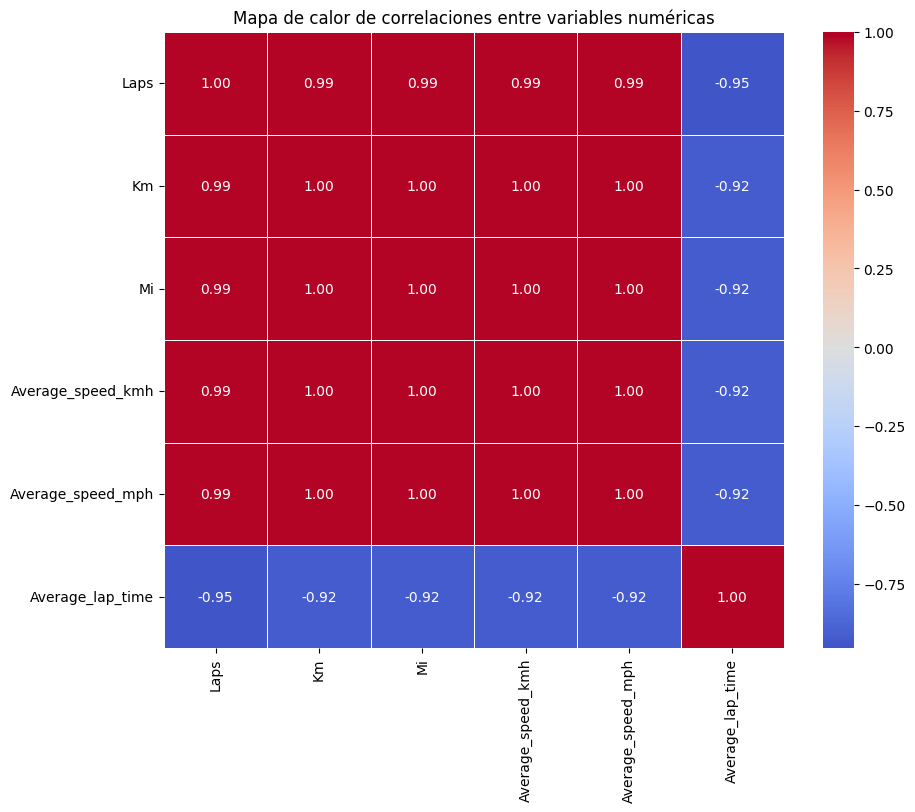

In [ ]:
# Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Mapa de calor de correlaciones entre variables numéricas')
plt.show()

Justificación: El coeficiente de Pearson asume normalidad y linealidad, pero es un buen punto de partida. El mapa de calor ayuda a visualizar rápidamente pares de variables altamente correlacionadas.

Interpretación esperada:

Km y Mi deben tener correlación casi perfecta (1.0) porque son conversiones directas. Esto indica redundancia; podríamos eliminar una.

Average_speed_kmh y Average_speed_mph también están casi perfectamente correlacionadas.

Average_speed_kmh y Year suelen tener correlación positiva fuerte (los coches son más rápidos con el tiempo).

Average_lap_time tiene correlación negativa con la velocidad (a mayor velocidad, menor tiempo por vuelta).

Laps puede estar correlacionado con Km (distancia total) pero no tanto con el año porque la longitud de la pista ha variado.

Este análisis permite decidir qué variables son más relevantes para futuros modelos de regresión (predecir velocidad media) o clasificación (predecir si un piloto es de cierta nacionalidad).

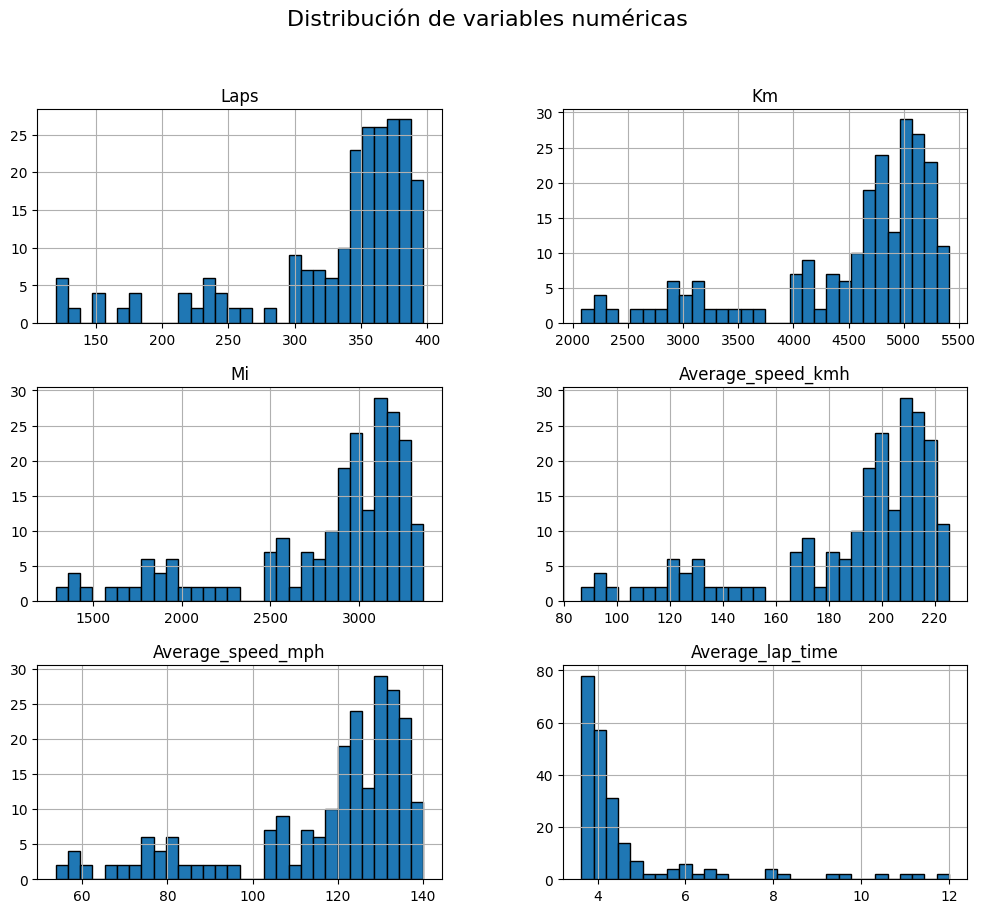

In [ ]:
# Histogramas de las variables numéricas originales
X_numeric.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.suptitle('Distribución de variables numéricas', size=16)
plt.show()

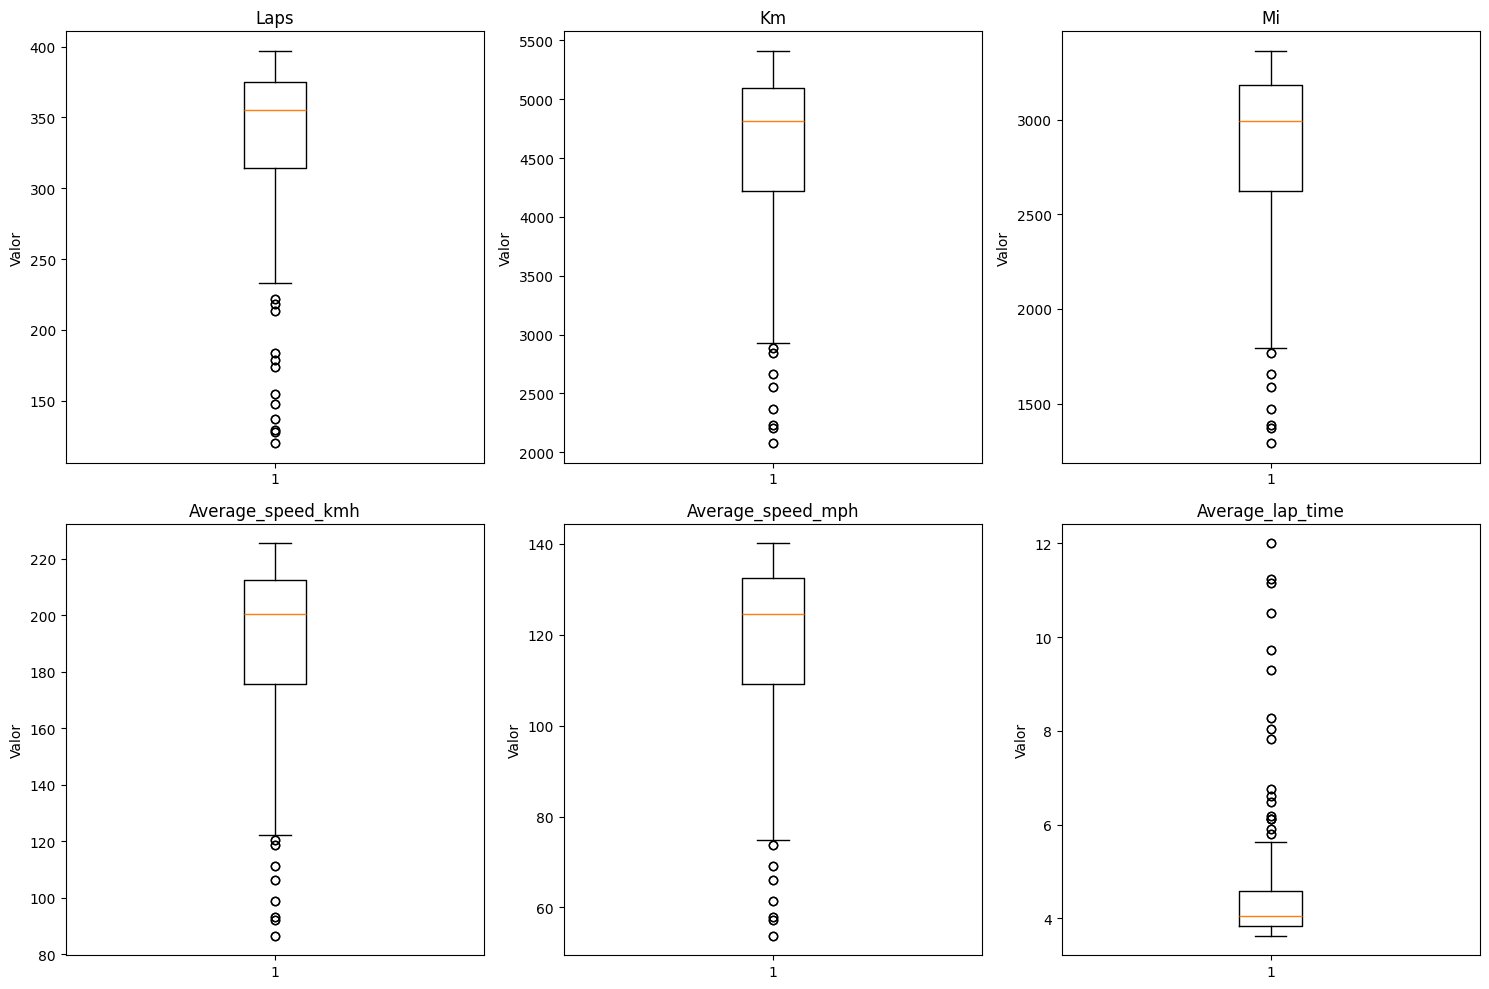

In [ ]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(X_numeric[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')
plt.tight_layout()
plt.show()

Interpretación:

Histogramas: Muestran la forma de la distribución. Average_speed_kmh tiene una distribución asimétrica positiva (aumenta con el tiempo). Laps tiene picos en ciertos valores debido a cambios en la longitud del circuito.

Boxplots: Revelan outliers. Por ejemplo, velocidades muy bajas en los primeros años, o vueltas muy altas en años con circuito más largo. Los outliers pueden ser años especiales (ej. 1930-1940) y no necesariamente errores.


## Conclusiones del análisis

1. **Calidad de datos**: El dataset no presenta valores nulos, lo que facilita el preprocesamiento.
2. **Tipos de datos**: Se identificaron 8 variables numéricas y 7 categóricas, todas transformadas correctamente.
3. **Encoding**: Aplicamos Label Encoding a columnas ordinales y One-Hot a equipos para evitar falsas relaciones numéricas.
4. **Escalado**: Se generaron versiones estandarizadas y normalizadas, listas para algoritmos sensibles a la escala.
5. **Correlación**: Alta redundancia entre **Km** y **Mi**, también entre **Average_speed_kmh** y **mph**. Se recomienda eliminar **Mi** y **mph** para reducir dimensionalidad.
6. **Outliers**: Las velocidades extremadamente bajas corresponden a los años 1920-1930, pero son datos reales y no deben eliminarse si el objetivo es estudiar la evolución histórica.

**Repositorio GitHub**: https://github.com/claudrojasp-cmyk/mineria_datos_clases/tree/main